# To Visualize data

https://geojson.io

use small sample like 100

In [ ]:
!unzip -q "Topo4Vec-peer-review (1).zip" -d topo4vec_project

In [ ]:
!find topo4vec_project -maxdepth 3 -type f | head -50

topo4vec_project/Topo4Vec-peer-review/05_geo2vec_training_inference_part2.ipynb
topo4vec_project/Topo4Vec-peer-review/pyproject.toml
topo4vec_project/Topo4Vec-peer-review/08_results_analysis.ipynb
topo4vec_project/Topo4Vec-peer-review/README.md
topo4vec_project/Topo4Vec-peer-review/__pycache__/test.cpython-37-pytest-5.2.1.pyc
topo4vec_project/Topo4Vec-peer-review/__pycache__/TopoVec.cpython-312.pyc
topo4vec_project/Topo4Vec-peer-review/__pycache__/test.cpython-310-pytest-7.4.0.pyc
topo4vec_project/Topo4Vec-peer-review/__pycache__/TopoVec.cpython-310.pyc
topo4vec_project/Topo4Vec-peer-review/TopoVec.py
topo4vec_project/Topo4Vec-peer-review/02_polygon_simulation.ipynb
topo4vec_project/Topo4Vec-peer-review/.gitignore
topo4vec_project/Topo4Vec-peer-review/.gitmodules
topo4vec_project/Topo4Vec-peer-review/05_geo2vec_training_inference_part1.ipynb
topo4vec_project/Topo4Vec-peer-review/figure/03_polyline_simulation.png
topo4vec_project/Topo4Vec-peer-review/figure/Study_area.png
topo4vec_proje

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving riyadh_buildings_clean.geojson to riyadh_buildings_clean.geojson


In [ ]:
import geopandas as gpd
buildings = gpd.read_file("/content/riyadh_buildings_clean.geojson")
print(buildings.shape)
buildings.head()

(782090, 4)


,height,confidence,feature_id,geometry
0,-1.0,-1.0,BLDG_0000001,"POLYGON ((46.67356 24.72151, 46.67348 24.72169..."
1,-1.0,-1.0,BLDG_0000002,"POLYGON ((46.40534 24.78541, 46.4054 24.78604,..."
2,-1.0,-1.0,BLDG_0000003,"POLYGON ((46.6736 24.80434, 46.67373 24.80438,..."
3,-1.0,-1.0,BLDG_0000004,"POLYGON ((46.40691 25.11747, 46.40695 25.11748..."
4,-1.0,-1.0,BLDG_0000005,"POLYGON ((46.67372 24.85615, 46.67399 24.85625..."


In [ ]:
buildings.geom_type.value_counts()

,count
Polygon,782090


In [ ]:
sample_buildings = buildings.sample(n=1000, random_state=42).copy()
print(sample_buildings.shape)

(1000, 4)


In [ ]:
print(buildings.shape)
buildings.geom_type.value_counts()

(782090, 4)


,count
Polygon,782090


In [ ]:
sample_buildings = buildings[["feature_id", "geometry"]].sample(n=1000, random_state=42).copy()
print(sample_buildings.shape)

(1000, 2)


In [ ]:
!pip install -q osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 9.3 MB/s eta 0:00:00


In [ ]:
import sys
sys.path.append("/content/topo4vec_project/Topo4Vec-peer-review")

from topovec.simulation import (
    simulate_pairs,
    verify_non_overlapping,
    results_to_geodataframe)

In [ ]:
non_overlap_pairs = simulate_pairs(
    sample_buildings,
    n=500,
    overlapped=False,
    scale_max=3,
    random_seed=42
)
non_overlap_pairs = verify_non_overlapping(non_overlap_pairs)
print("Non-overlap:", len(non_overlap_pairs))

Non-overlap: 267


In [ ]:
overlap_pairs = simulate_pairs(
    sample_buildings,
    n=500,
    overlapped=True,
    scale_max=3,
    random_seed=42
)
print("Overlap:", len(overlap_pairs))

Overlap: 500


In [ ]:
valid_non_overlap = list(non_overlap_pairs)
seed = 43
while len(valid_non_overlap) < 500:
    new_pairs = simulate_pairs(
        sample_buildings,
        n=500,
        overlapped=False,
        scale_max=3,
        random_seed=seed
    )

    new_pairs = verify_non_overlapping(new_pairs)
    valid_non_overlap.extend(new_pairs)

    seed += 1

non_overlap_pairs = valid_non_overlap[:500]
print("Non-overlap:", len(non_overlap_pairs))
print("Overlap:", len(overlap_pairs))

Non-overlap: 500
Overlap: 500


In [ ]:
non_overlap_gdf = results_to_geodataframe(non_overlap_pairs)
overlap_gdf = results_to_geodataframe(overlap_pairs)

print("Non-overlap GDF:", non_overlap_gdf.shape)
print("Overlap GDF:", overlap_gdf.shape)

Non-overlap GDF: (1000, 2)
Overlap GDF: (1500, 2)


In [ ]:
non_overlap_gdf = results_to_geodataframe(non_overlap_pairs)
overlap_gdf = results_to_geodataframe(overlap_pairs)

print(non_overlap_gdf.shape)
print(overlap_gdf.shape)

non_overlap_gdf.head()

(1000, 2)
(1500, 2)


,geometry,role
0,"POLYGON ((0.36636 0.34262, 0.28954 0.31968, 0....",p1
1,"POLYGON ((0.61973 0.13412, 0.7777 0, 0.95573 0...",p2
2,"POLYGON ((0 0.25737, 0.35811 0, 0.49602 0.1587...",p1
3,"POLYGON ((0 0.68693, 0.16363 0.42956, 0.46285 ...",p2
4,"POLYGON ((0.37796 0, 0.57667 0.19654, 0.19871 ...",p1


<Axes: >

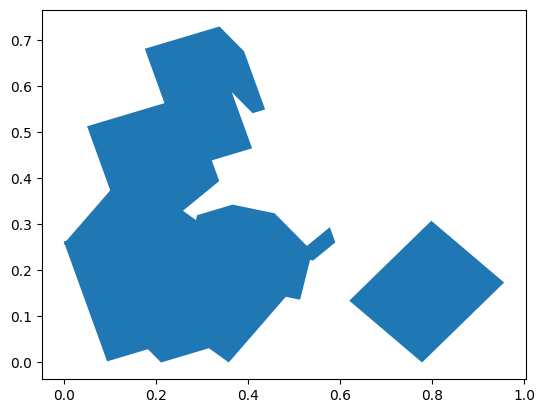

In [ ]:
non_overlap_gdf.iloc[:3].plot()

<Axes: >

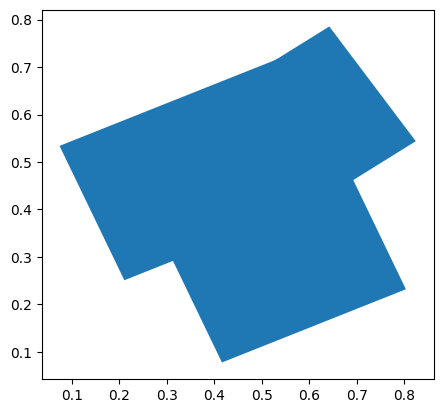

In [ ]:
overlap_gdf.iloc[:3].plot()

In [ ]:
!git clone https://github.com/chuchen2017/GeoNeuralRepresentation.git \
"/content/topo4vec_project/Topo4Vec-peer-review/topovec/Geo2Vec"

Cloning into '/content/topo4vec_project/Topo4Vec-peer-review/topovec/Geo2Vec'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 209 (delta 70), reused 116 (delta 40), pack-reused 59 (from 2)
Receiving objects: 100% (209/209), 107.76 MiB | 19.82 MiB/s, done.
Resolving deltas: 100% (84/84), done.


In [ ]:
import os

geo2vec_path = "/content/topo4vec_project/Topo4Vec-peer-review/topovec/Geo2Vec"

print("Exists:", os.path.exists(geo2vec_path))
print("Files:", os.listdir(geo2vec_path)[:20] if os.path.exists(geo2vec_path) else "Not found")

Exists: True
Files: ['configs', '__init__.py', 'main.py', 'requirements.txt', '__pycache__', 'models', '.git', '.gitignore', 'pics', 'data', 'runners', '.vscode', 'readme.md', 'tutorial.ipynb', 'utils']


In [ ]:
import sys
sys.path.append(geo2vec_path)
from runners import list2embedding
print("Geo2Vec imported successfully!")

Geo2Vec imported successfully!


In [ ]:
geolist = []
geo_pairs_list = []
relations = []

index = 0

# 500 Non-overlap → label 0
for pair in non_overlap_pairs:
    geolist.append(pair["p1"])
    geolist.append(pair["p2"])

    geo_pairs_list.append((index, index + 1))
    relations.append(0)

    index += 2

# 500 Overlap → label 1
for pair in overlap_pairs:
    geolist.append(pair["p1"])
    geolist.append(pair["p2"])

    geo_pairs_list.append((index, index + 1))
    relations.append(1)

    index += 2

print("Polygons:", len(geolist))
print("Pairs:", len(geo_pairs_list))
print("Labels:", len(relations))
print("Non-overlap labels:", relations.count(0))
print("Overlap labels:", relations.count(1))

Polygons: 2000
Pairs: 1000
Labels: 1000
Non-overlap labels: 500
Overlap labels: 500


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
test_geolist = geolist[:20]
print("Testing Geo2Vec on", len(test_geolist), "polygons...")

Testing Geo2Vec on 20 polygons...


In [ ]:
import sys

# حل مشكلة Colab arguments
old_argv = sys.argv
sys.argv = [sys.argv[0]]

args = list2embedding.get_args()

sys.argv = old_argv

# تشغيل تجربة صغيرة
test_embeddings = list2embedding.list2vec(
    test_geolist,
    Geo_dim=128,
    num_epoch=1,
    args=args
)

print("Test embedding shape:", test_embeddings.shape)

Bounding box: (-0.1, 1.1, -0.1, 1.1)
Sampling progress: 0.0%


100%|██████████| 10/10 [00:02<00:00,  3.35it/s]


Sampling progress: 50.0%


100%|██████████| 10/10 [00:01<00:00,  5.45it/s]


In average training samples per entity: 7266.1


...

In average training samples per entity: 795.6


Training...: 100%|██████████| 1/1 [00:00<00:00,  5.95it/s]

Epoch 1/1, Loss: 2066.244140625, TEST Loss: 0.13806739449501038


Training...: 100%|██████████| 1/1 [00:00<00:00,  5.88it/s]

Test embedding shape: (20, 256)


In [ ]:
embeddings = list2embedding.list2vec(
    geolist,
    Geo_dim=128,
    num_epoch=1,
    args=args
)

print("All embeddings shape:", embeddings.shape)

Bounding box: (-0.1, 1.1, -0.1, 1.1)
Sampling progress: 0.0%


100%|██████████| 1000/1000 [01:07<00:00, 14.80it/s]


Sampling progress: 50.0%


100%|██████████| 1000/1000 [01:15<00:00, 13.30it/s]


In average training samples per entity: 7554.3015


...

Sampling progress: 50.0%


100%|██████████| 1000/1000 [00:35<00:00, 27.94it/s]


In average training samples per entity: 777.2685


Training...: 100%|██████████| 1/1 [00:13<00:00, 13.35s/it]

Epoch 1/1, Loss: 1189.7786969636616, TEST Loss: 0.15021353214979172
All embeddings shape: (2000, 256)


In [ ]:
import numpy as np

X = []

for i1, i2 in geo_pairs_list:
    pair_embedding = np.concatenate([
        embeddings[i1],
        embeddings[i2]
    ])
    X.append(pair_embedding)

X = np.array(X)
y = np.array(relations)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 512)
y shape: (1000,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-overlap", "Overlap"]
))

Accuracy: 0.91
              precision    recall  f1-score   support

 Non-overlap       0.94      0.88      0.91       100
     Overlap       0.89      0.94      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



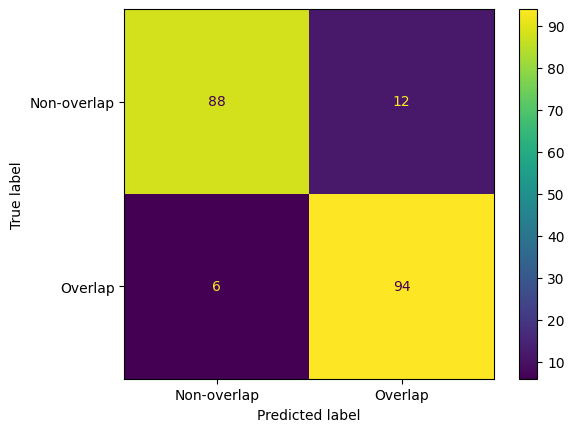

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-overlap", "Overlap"]
)

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": y_pred
})

results.to_csv("topo4vec_building_results.csv", index=False)

print("Saved!")

Saved!


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import ast
import random
import json
import matplotlib.pyplot as plt

from shapely.geometry import LineString, Point

In [ ]:
roads = gpd.read_file("/content/riyadh_roads_clean.geojson")
connectors = gpd.read_file("/content/riyadh_connectors_clean.geojson")

print("Roads:", roads.shape)
print("Connectors:", connectors.shape)

print("\nRoad geometry:")
print(roads.geom_type.value_counts())

print("\nConnector geometry:")
print(connectors.geom_type.value_counts())

/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'level_rules' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Roads: (291878, 20)
Connectors: (249934, 4)

Road geometry:
LineString         291866
MultiLineString        12
Name: count, dtype: int64

Connector geometry:
Point    249934
Name: count, dtype: int64


In [ ]:
print("Road CRS:", roads.crs)
print("Connector CRS:", connectors.crs)

Road CRS: EPSG:4326
Connector CRS: EPSG:4326


In [ ]:
def parse_connectors(value):
    if isinstance(value, list):
        return value

    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []

    return []

In [ ]:
def get_road_endpoints(value):
    conns = parse_connectors(value)

    start_id = None
    end_id = None

    for c in conns:
        if c.get("at") == 0.0:
            start_id = c.get("connector_id")

        elif c.get("at") == 1.0:
            end_id = c.get("connector_id")

    return start_id, end_id

In [ ]:
roads[["start_connector", "end_connector"]] = roads["connectors"].apply(
    lambda x: pd.Series(get_road_endpoints(x))
)

print(roads[["id", "start_connector", "end_connector"]].head())

                                     id                       start_connector  \
0  3199b94d-e808-46b9-8f80-fca50eabb279  7ed52e08-ef27-40f9-84cf-bfe1f391832c   
1  e58462aa-afce-4cc2-a49f-350d907727bf  fb04d61c-2c09-43c9-baf9-33e49729e4bd   
2  7d298770-0506-4a4d-8581-55f688d79a91  89332955-ce4b-46fb-b032-06190059ae04   
3  1d6e5915-acae-47b2-ae1d-8973f7ce1962  8da05dc7-98f7-4fc3-b396-b668043af644   
4  b80066ac-fec4-4653-aa31-1bd41c2f151a  89332955-ce4b-46fb-b032-06190059ae04   

                          end_connector  
0  4c51dc05-d425-4bbc-8f19-5e09c87eb12a  
1  ebb9ca77-50b1-4cc2-a9b4-4d613bd5cd42  
2  346e1637-db26-48ac-9490-164e6117ab56  
3  89332955-ce4b-46fb-b032-06190059ae04  
4  7fec23ca-ad57-4b1c-b485-b2e8f5c66464  


In [ ]:
roads_valid = roads.dropna(
    subset=["start_connector", "end_connector"]
).copy()

print("Valid roads:", len(roads_valid))

Valid roads: 291878


In [ ]:
connector_ids = set(connectors["id"])

roads_valid = roads_valid[
    roads_valid["start_connector"].isin(connector_ids) &
    roads_valid["end_connector"].isin(connector_ids)
].copy()

print("Roads with valid connectors:", len(roads_valid))

Roads with valid connectors: 291480


In [ ]:
connector_lookup = connectors.set_index("id")["geometry"].to_dict()

print("Connector lookup:", len(connector_lookup))

Connector lookup: 249934


In [ ]:
G = nx.MultiDiGraph()

# nodes
for connector_id, geom in connector_lookup.items():
    G.add_node(
        connector_id,
        x=geom.x,
        y=geom.y
    )

print("Nodes added:", G.number_of_nodes())

Nodes added: 249934


In [ ]:
for idx, row in roads_valid.iterrows():
    G.add_edge(
        row["start_connector"],
        row["end_connector"],
        key=row["id"],
        road_index=idx
    )

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

Graph nodes: 249934
Graph edges: 291480


In [ ]:
degrees = dict(G.degree())

seed_node = max(degrees, key=degrees.get)

print("Seed connector:", seed_node)
print("Degree:", degrees[seed_node])

Seed connector: ef29c6fe-5ced-43ac-9ee4-1a3c53371db7
Degree: 9


In [ ]:
selected_edges = []
visited_nodes = set()
queue = [seed_node]

while queue and len(selected_edges) < 1000:

    node = queue.pop(0)

    if node in visited_nodes:
        continue

    visited_nodes.add(node)

    for u, v, key, data in G.edges(node, keys=True, data=True):

        selected_edges.append(data["road_index"])

        if v not in visited_nodes:
            queue.append(v)

        if len(selected_edges) >= 1000:
            break


selected_edges = list(dict.fromkeys(selected_edges))[:1000]

roads_sample = roads_valid.loc[selected_edges].copy()

print("Selected roads:", len(roads_sample))

Selected roads: 1000


In [ ]:
print(roads_sample.shape)
print(roads_sample.geom_type.value_counts())

(1000, 22)
LineString    1000
Name: count, dtype: int64


In [ ]:
G_sample = nx.MultiDiGraph()

graph_edge_to_id = {}

clean_geometry = []

for local_id, (_, row) in enumerate(roads_sample.iterrows()):

    u = row["start_connector"]
    v = row["end_connector"]

    u_geom = connector_lookup[u]
    v_geom = connector_lookup[v]

    G_sample.add_node(u, x=u_geom.x, y=u_geom.y)
    G_sample.add_node(v, x=v_geom.x, y=v_geom.y)

    G_sample.add_edge(
        u,
        v,
        key=local_id
    )

    graph_edge_to_id[(u, v, local_id)] = local_id

    clean_geometry.append(row.geometry)


print("Sample nodes:", G_sample.number_of_nodes())
print("Sample edges:", G_sample.number_of_edges())
print("Geometries:", len(clean_geometry))

Sample nodes: 733
Sample edges: 1000
Geometries: 1000


In [ ]:
import sys

sys.path.append(
    "/content/topo4vec_project/Topo4Vec-peer-review"
)

In [ ]:
from TopoVec import apply_stochastic_errors

print("Topo4Vec polyline simulation ready")

Topo4Vec polyline simulation ready


In [ ]:
random.seed(42)
np.random.seed(42)

In [ ]:
(
    corrupted_geometry,
    corrupted_flags,
    new_corrupted_nodes,
    error_types,
    neighborhood_ids
) = apply_stochastic_errors(

    clean_geometry,
    G_sample,
    graph_edge_to_id,

    error_rate=0.50,
    mu_magnitude=0.4,
    sigma_magnitude=0.3
)

Target corruption count: 500 (rate=0.5). Valid candidates: 943
Corrupted 398 edges after applying neighbour-protection constraints.


In [ ]:
print("Total roads:", len(clean_geometry))
print("Corrupted roads:", sum(corrupted_flags))

from collections import Counter

print(Counter(
    x for x in error_types
    if x is not None
))

Total roads: 1000
Corrupted roads: 398
Counter({'undershoot': 215, 'overshoot': 183})


In [ ]:
clean_gdf = gpd.GeoDataFrame(
    {
        "edge_id": range(len(clean_geometry)),
        "is_corrupted": False,
        "error_type": None
    },
    geometry=clean_geometry,
    crs=roads_sample.crs
)

clean_gdf.head()

,edge_id,is_corrupted,error_type,geometry
0,0,False,None,"LINESTRING (46.71638 24.70437, 46.7161 24.7040..."
1,1,False,None,"LINESTRING (46.71638 24.70437, 46.71589 24.704..."
2,2,False,None,"LINESTRING (46.71638 24.70437, 46.71589 24.70456)"
3,3,False,None,"LINESTRING (46.71638 24.70437, 46.71652 24.704..."
4,4,False,None,"LINESTRING (46.71586 24.70354, 46.71604 24.703..."


In [ ]:
corrupted_gdf = gpd.GeoDataFrame(
    {
        "edge_id": range(len(corrupted_geometry)),
        "is_corrupted": corrupted_flags,
        "error_type": error_types
    },
    geometry=corrupted_geometry,
    crs=roads_sample.crs
)

corrupted_gdf.head()

,edge_id,is_corrupted,error_type,geometry
0,0,False,None,"LINESTRING (46.71638 24.70437, 46.7161 24.7040..."
1,1,True,overshoot,"LINESTRING (46.71651 24.7044, 46.71589 24.7042..."
2,2,False,None,"LINESTRING (46.71638 24.70437, 46.71589 24.70456)"
3,3,False,None,"LINESTRING (46.71638 24.70437, 46.71652 24.704..."
4,4,False,None,"LINESTRING (46.71586 24.70354, 46.71604 24.703..."


In [ ]:
print(
    corrupted_gdf["error_type"]
    .fillna("clean")
    .value_counts()
)

error_type
clean         602
undershoot    215
overshoot     183
Name: count, dtype: int64


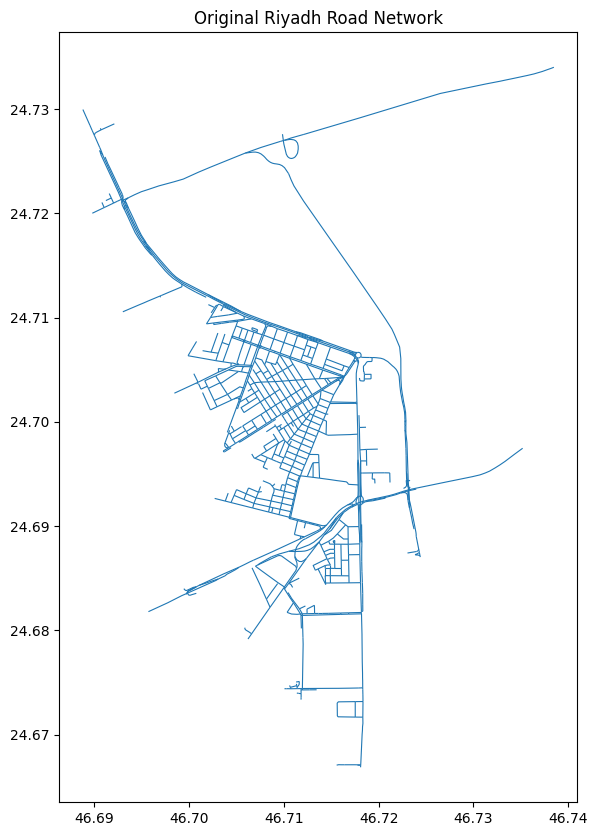

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

clean_gdf.plot(
    ax=ax,
    linewidth=0.8
)

ax.set_title("Original Riyadh Road Network")
plt.show()

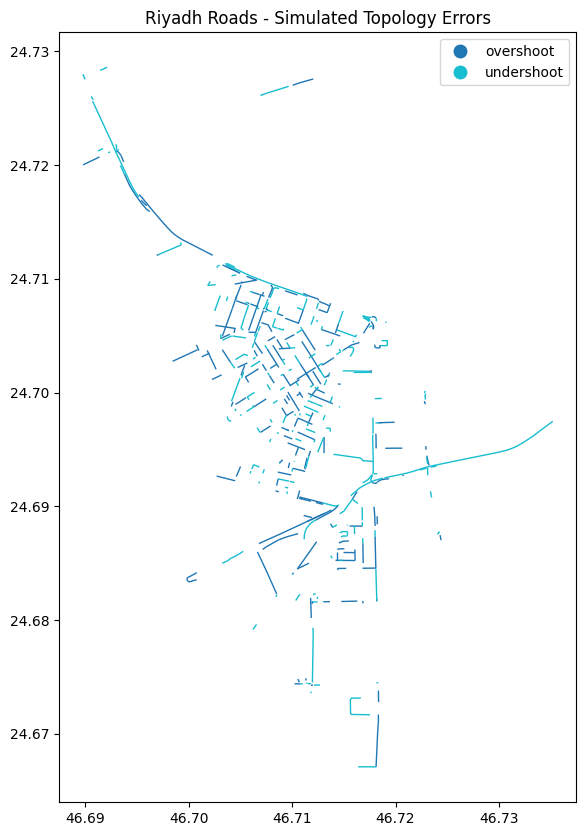

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

corrupted_gdf.plot(
    ax=ax,
    column="error_type",
    legend=True,
    linewidth=1
)

ax.set_title("Riyadh Roads - Simulated Topology Errors")
plt.show()

In [ ]:
overshoot_examples = corrupted_gdf[
    corrupted_gdf["error_type"] == "overshoot"
]

print("Overshoot:", len(overshoot_examples))

overshoot_examples.head()

Overshoot: 183


,edge_id,is_corrupted,error_type,geometry
1,1,True,overshoot,"LINESTRING (46.71651 24.7044, 46.71589 24.7042..."
11,11,True,overshoot,"LINESTRING (46.71463 24.70498, 46.71333 24.705..."
12,12,True,overshoot,"LINESTRING (46.7178 24.70583, 46.71782 24.7057..."
13,13,True,overshoot,"LINESTRING (46.71751 24.70611, 46.7169 24.70522)"
17,17,True,overshoot,"LINESTRING (46.71418 24.70524, 46.71447 24.70604)"


In [ ]:
undershoot_examples = corrupted_gdf[
    corrupted_gdf["error_type"] == "undershoot"
]

print("Undershoot:", len(undershoot_examples))

undershoot_examples.head()

Undershoot: 215


,edge_id,is_corrupted,error_type,geometry
5,5,True,undershoot,"LINESTRING (46.71497 24.70374, 46.71483 24.70366)"
7,7,True,undershoot,"LINESTRING (46.71745 24.70574, 46.71753 24.705..."
9,9,True,undershoot,"LINESTRING (46.7147 24.70359, 46.71427 24.70334)"
16,16,True,undershoot,"LINESTRING (46.71429 24.70553, 46.71614 24.704..."
18,18,True,undershoot,"LINESTRING (46.71282 24.70555, 46.71293 24.70584)"


In [ ]:
clean_gdf.to_file(
    "/content/riyadh_roads_reference.geojson",
    driver="GeoJSON"
)

corrupted_gdf.to_file(
    "/content/riyadh_roads_corrupted.geojson",
    driver="GeoJSON"
)

print("Saved")

Saved


In [ ]:
ground_truth = corrupted_gdf[
    ["edge_id", "is_corrupted", "error_type"]
].copy()

ground_truth["domain"] = "roads"
ground_truth["injection_method"] = "Topo4Vec polyline simulation"
ground_truth["seed"] = 42

ground_truth.to_csv(
    "/content/riyadh_roads_ground_truth.csv",
    index=False
)

ground_truth.head()

,edge_id,is_corrupted,error_type,domain,injection_method,seed
0,0,False,None,roads,Topo4Vec polyline simulation,42
1,1,True,overshoot,roads,Topo4Vec polyline simulation,42
2,2,False,None,roads,Topo4Vec polyline simulation,42
3,3,False,None,roads,Topo4Vec polyline simulation,42
4,4,False,None,roads,Topo4Vec polyline simulation,42


In [ ]:
print("Total samples:", len(ground_truth))

print("\nClasses:")
print(
    ground_truth["error_type"]
    .fillna("clean")
    .value_counts()
)

print("\nCorrupted:")
print(ground_truth["is_corrupted"].value_counts())

Total samples: 1000

Classes:
error_type
clean         602
undershoot    215
overshoot     183
Name: count, dtype: int64

Corrupted:
is_corrupted
False    602
True     398
Name: count, dtype: int64


In [ ]:
# Dataset for Overshoot detection
overshoot_data = corrupted_gdf[
    corrupted_gdf["error_type"].isin(["overshoot"]) |
    corrupted_gdf["error_type"].isna()
].copy()

overshoot_data["label"] = (
    overshoot_data["error_type"] == "overshoot"
).astype(int)

print("Overshoot dataset:")
print(overshoot_data["label"].value_counts())


# Dataset for Undershoot detection
undershoot_data = corrupted_gdf[
    corrupted_gdf["error_type"].isin(["undershoot"]) |
    corrupted_gdf["error_type"].isna()
].copy()

undershoot_data["label"] = (
    undershoot_data["error_type"] == "undershoot"
).astype(int)

print("\nUndershoot dataset:")
print(undershoot_data["label"].value_counts())

Overshoot dataset:
label
0    602
1    183
Name: count, dtype: int64

Undershoot dataset:
label
0    602
1    215
Name: count, dtype: int64


In [ ]:
overshoot_geolist = overshoot_data.geometry.tolist()
overshoot_labels = overshoot_data["label"].to_numpy()

print("Geometries:", len(overshoot_geolist))
print("Labels:", len(overshoot_labels))
print("Clean:", (overshoot_labels == 0).sum())
print("Overshoot:", (overshoot_labels == 1).sum())

Geometries: 785
Labels: 785
Clean: 602
Overshoot: 183


In [ ]:
old_argv = sys.argv
sys.argv = [sys.argv[0]]

args = list2embedding.get_args()

sys.argv = old_argv

print("Args ready")

Args ready


In [ ]:
args.num_process = 2

args.samples_perUnit_location = 2000
args.point_sample_location = 100
args.uniformed_sample_perUnit_location = 50

print("Fast PoC settings ready")

Fast PoC settings ready


In [ ]:
test_roads = overshoot_geolist[:20]

test_road_embeddings = list2embedding.list2vec(
    test_roads,
    Geo_dim=128,
    num_epoch=1,
    location_learning=True,
    shape_learning=False,
    args=args
)

print("Test shape:", test_road_embeddings.shape)

Bounding box: (-0.1, 1.1, -0.1, 1.1)
Sampling progress: 0.0%


100%|██████████| 10/10 [00:01<00:00,  7.48it/s]

Sampling progress: 50.0%



100%|██████████| 10/10 [00:01<00:00,  5.48it/s]


In average training samples per entity: 3172.95


Training...: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]

Epoch 1/1, Loss: 5082.507080078125, TEST Loss: 0.26620492339134216
Test shape: (20, 128)


In [ ]:
overshoot_embeddings = list2embedding.list2vec(
    overshoot_geolist,
    Geo_dim=128,
    num_epoch=1,
    location_learning=True,
    shape_learning=False,
    args=args
)

print("Overshoot embeddings shape:",
      overshoot_embeddings.shape)

Bounding box: (-0.1, 1.1, -0.1, 1.1)
Sampling progress: 0.0%


100%|██████████| 393/393 [00:51<00:00,  7.62it/s]

Sampling progress: 50.0%



100%|██████████| 392/392 [00:40<00:00,  9.78it/s]


In average training samples per entity: 2711.4929936305734


Training...: 100%|██████████| 1/1 [00:09<00:00,  9.89s/it]

Epoch 1/1, Loss: 1137.1504434438853, TEST Loss: 0.06888866983354092
Overshoot embeddings shape: (785, 128)


In [ ]:
np.save(
    "/content/overshoot_embeddings.npy",
    overshoot_embeddings
)

np.save(
    "/content/overshoot_labels.npy",
    overshoot_labels
)

print("Saved")

Saved


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    overshoot_embeddings,
    overshoot_labels,
    test_size=0.2,
    random_state=42,
    stratify=overshoot_labels
)

print("Train:", X_train_o.shape)
print("Test:", X_test_o.shape)

mlp_overshoot = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    random_state=42
)

mlp_overshoot.fit(X_train_o, y_train_o)

print("Overshoot MLP trained")

Train: (628, 128)
Test: (157, 128)
Overshoot MLP trained


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred_o = mlp_overshoot.predict(X_test_o)

print("Accuracy:", accuracy_score(y_test_o, y_pred_o))

print(
    classification_report(
        y_test_o,
        y_pred_o,
        target_names=["Clean", "Overshoot"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test_o, y_pred_o))

Accuracy: 0.6305732484076433
              precision    recall  f1-score   support

       Clean       0.75      0.77      0.76       120
   Overshoot       0.20      0.19      0.19        37

    accuracy                           0.63       157
   macro avg       0.48      0.48      0.48       157
weighted avg       0.62      0.63      0.63       157

Confusion Matrix:
[[92 28]
 [30  7]]


In [ ]:
undershoot_geolist = undershoot_data.geometry.tolist()
undershoot_labels = undershoot_data["label"].to_numpy()

print("Geometries:", len(undershoot_geolist))
print("Labels:", len(undershoot_labels))
print("Clean:", (undershoot_labels == 0).sum())
print("Undershoot:", (undershoot_labels == 1).sum())

Geometries: 817
Labels: 817
Clean: 602
Undershoot: 215


In [ ]:
test_undershoot = undershoot_geolist[:20]

test_undershoot_embeddings = list2embedding.list2vec(
    test_undershoot,
    Geo_dim=128,
    num_epoch=1,
    location_learning=True,
    shape_learning=False,
    args=args
)

print("Test shape:", test_undershoot_embeddings.shape)

Bounding box: (-0.1, 1.1, -0.1, 1.1)
Sampling progress: 0.0%


100%|██████████| 10/10 [00:01<00:00,  5.34it/s]

Sampling progress: 50.0%



100%|██████████| 10/10 [00:01<00:00,  8.36it/s]


In average training samples per entity: 3122.0


Training...: 100%|██████████| 1/1 [00:00<00:00,  2.94it/s]

Epoch 1/1, Loss: 5175.774307250977, TEST Loss: 0.2955787479877472
Test shape: (20, 128)


In [ ]:
undershoot_embeddings = list2embedding.list2vec(
    undershoot_geolist,
    Geo_dim=128,
    num_epoch=1,
    location_learning=True,
    shape_learning=False,
    args=args
)

print(
    "Undershoot embeddings shape:",
    undershoot_embeddings.shape
)

Bounding box: (-0.1, 1.1, -0.1, 1.1)
Sampling progress: 0.0%


100%|██████████| 409/409 [00:49<00:00,  8.23it/s]

Sampling progress: 50.0%



100%|██████████| 408/408 [00:40<00:00, 10.09it/s]


In average training samples per entity: 2713.734394124847


Training...: 100%|██████████| 1/1 [00:09<00:00,  9.44s/it]

Epoch 1/1, Loss: 1071.7912677099946, TEST Loss: 0.09607161954045296
Undershoot embeddings shape: (817, 128)


In [ ]:
np.save(
    "/content/undershoot_embeddings.npy",
    undershoot_embeddings
)

np.save(
    "/content/undershoot_labels.npy",
    undershoot_labels
)

print("Saved")

Saved


In [ ]:
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    undershoot_embeddings,
    undershoot_labels,
    test_size=0.2,
    random_state=42,
    stratify=undershoot_labels
)

print("Train:", X_train_u.shape)
print("Test:", X_test_u.shape)

Train: (653, 128)
Test: (164, 128)


In [ ]:
mlp_undershoot = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    random_state=42
)

mlp_undershoot.fit(
    X_train_u,
    y_train_u
)

print("Undershoot MLP trained")

Undershoot MLP trained


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
y_pred_u = mlp_undershoot.predict(X_test_u)

print(
    "Accuracy:",
    accuracy_score(y_test_u, y_pred_u)
)

print(
    classification_report(
        y_test_u,
        y_pred_u,
        target_names=["Clean", "Undershoot"]
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(y_test_u, y_pred_u)
)

Accuracy: 0.6402439024390244
              precision    recall  f1-score   support

       Clean       0.73      0.81      0.77       121
  Undershoot       0.23      0.16      0.19        43

    accuracy                           0.64       164
   macro avg       0.48      0.49      0.48       164
weighted avg       0.60      0.64      0.62       164

Confusion Matrix:
[[98 23]
 [36  7]]


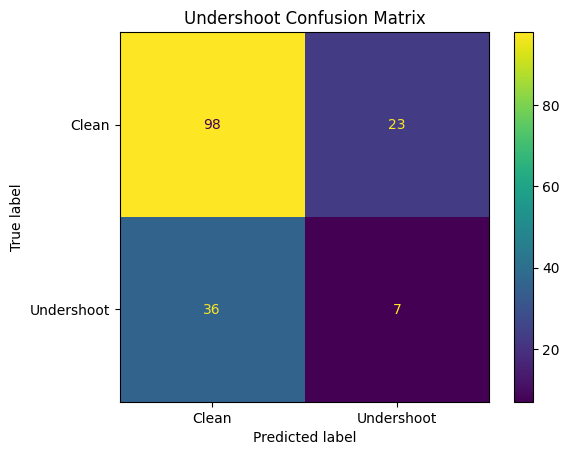

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_u,
    y_pred_u,
    display_labels=["Clean", "Undershoot"]
)

plt.title("Undershoot Confusion Matrix")
plt.show()

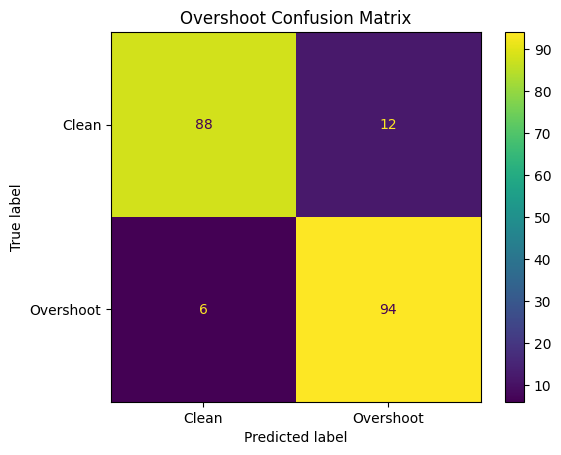

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_o,
    y_pred_o,
    display_labels=["Clean", "Overshoot"]
)

plt.title("Overshoot Confusion Matrix")
plt.show()

In [ ]:
overshoot_accuracy = accuracy_score(
    y_test_o,
    y_pred_o
)

undershoot_accuracy = accuracy_score(
    y_test_u,
    y_pred_u
)

print("Overshoot Accuracy:", overshoot_accuracy)
print("Undershoot Accuracy:", undershoot_accuracy)

Overshoot Accuracy: 0.6305732484076433
Undershoot Accuracy: 0.6402439024390244
